# Lecture 8, Supplement 1 — How a band feature is actually computed

### From a sampled wave to `e_1x`, `e_2x`, `e_bpfo`, `e_hi` — and whether to use an FFT or Goertzel

**01211271 Industrial AI and IoT** · Electromechanical Manufacturing Engineering

---

Lecture 8 used four frequency-domain features and told you what they mean. It did not
tell you where the numbers come from, and several of you have asked — reasonably —
questions that the main lecture skipped:

* *Why 2000 Hz? Why 256 samples?*
* *What is a "bin", and why can I not just ask for the power at 30 Hz?*
* *Why does my ESP32 give a different `e_1x` from the notebook, using the same window?*
* *The Lab 8 file has a `goertzel()` function that nothing calls. What is it for, and
  when should I use it instead of an FFT?*

This notebook answers all four, from the beginning, with no assumed background beyond
trigonometry. There is no new material for the exam here — it is the floor underneath
Lecture 8, and everything in it is arithmetic you can check by hand.

### What you will be able to do afterwards

1. Say what a sample rate buys you and what it costs, and recognise aliasing when you see
   it.
2. Work out the bin width of any window, and count how many bins a named band contains.
3. Explain spectral leakage, and why the window function matters more than the algorithm.
4. Implement both a radix-2 FFT and Goertzel, show they give the same answer, and
   **choose between them with a number rather than a preference.**

### Prerequisites

`week8_common.py` and `spectral.py` in the same folder as this notebook. Both are in
`Lecture8_Supplement1_Code.zip`. `week8_common.py` is exactly the file from Lab 8.

In [1]:
import math, cmath, platform
import numpy as np
import matplotlib.pyplot as plt

print("python", platform.python_version(), "· numpy", np.__version__)

python 3.11.15 · numpy 2.4.4


## 1. A sample is a number, and a rate is a promise

An accelerometer produces a continuous voltage. The ADC on the ESP32 reads it
2000 times a second and throws everything between readings away. That rate is
the only decision in this whole notebook that **cannot be undone later in software**.

Our rig turns at about 30 Hz. At 2000 Hz that is
**67 samples per revolution**, which is comfortable. The reason for
2000 Hz is not the shaft, though — it is the bearing housing resonance at 600 Hz,
which is where a spall's energy actually lands. You need a sample rate comfortably above
twice that.

In [2]:
import week8_common as w8
import spectral as sp

FS, N = sp.FS, sp.WIN
print(f"sample rate   {FS:.0f} Hz")
print(f"window        {N} samples = {N/FS*1000:.0f} ms")
print(f"Nyquist       {FS/2:.0f} Hz   — the highest frequency that survives sampling")

rng = np.random.default_rng(11)
x_run, params = w8.make_run(rng, "bearing", seconds=1.0)
x = x_run[:N]                                  # THE demo window, used throughout
print(f"\nthis window's shaft rate  {params['f_r']:.2f} Hz")
print(f"its BPFO (3.6 x shaft)    {params['f_r']*w8.BPFO_RATIO:.1f} Hz")

sample rate   2000 Hz
window        256 samples = 128 ms
Nyquist       1000 Hz   — the highest frequency that survives sampling

this window's shaft rate  28.51 Hz
its BPFO (3.6 x shaft)    102.7 Hz


### Aliasing — the one mistake you cannot fix afterwards

Sample a 1700 Hz vibration at 2000 Hz and every sample you take also lies exactly on a
300 Hz sine. Nothing downstream can tell the two apart, because the information that
would distinguish them was never recorded. The 1700 Hz component does not disappear; it
**moves** to 300 Hz and sits there looking like a real feature.

This is why a data-acquisition front end has an analogue low-pass filter *before* the
ADC, not after it.

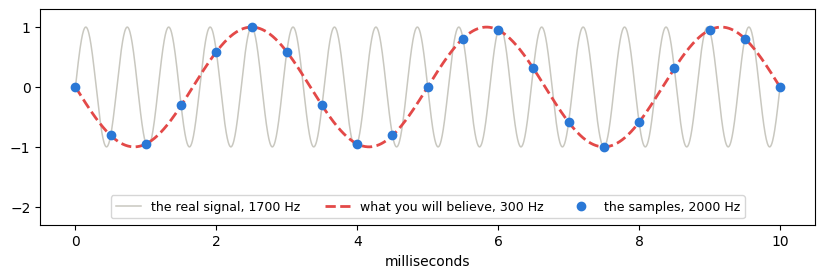

a 1700 Hz component sampled at 2000 Hz appears at 300 Hz, and no software can move it back


In [3]:
f_true = 1700.0
f_alias = abs(f_true - FS)
t_dense = np.arange(0, 0.010, 1/200000)
t_samp = np.arange(0, 0.0101, 1/FS)

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(t_dense*1000, np.sin(2*np.pi*f_true*t_dense), color="#c9c8c0", lw=1.1,
        label=f"the real signal, {f_true:.0f} Hz")
ax.plot(t_dense*1000, np.sin(2*np.pi*f_alias*t_dense + np.pi), "--", color="#e34948",
        lw=2, label=f"what you will believe, {f_alias:.0f} Hz")
ax.plot(t_samp*1000, np.sin(2*np.pi*f_true*t_samp), "o", ms=6, color="#2a78d6",
        label=f"the samples, {FS:.0f} Hz", zorder=5)
ax.set_xlabel("milliseconds"); ax.legend(fontsize=9, ncol=3, loc="lower center")
ax.set_ylim(-2.3, 1.3); plt.show()

print(f"a {f_true:.0f} Hz component sampled at {FS:.0f} Hz appears at "
      f"{f_alias:.0f} Hz, and no software can move it back")

## 2. The DFT is not magic — it is a bank of correlations

Take your window of $N$ samples. Pick a test wave. Multiply the two together sample by
sample and add up the result.

* If the test wave matches something in your signal, the products line up and the sum is
  large.
* If it does not, positive and negative products cancel and the sum is near zero.

That is the whole idea. The Discrete Fourier Transform does exactly this for $N$ test
waves, and the $k$-th answer is

$$X[k] \;=\; \sum_{n=0}^{N-1} x[n]\, e^{-j 2\pi k n / N}
\;=\; \underbrace{\sum_n x[n]\cos\!\Big(\tfrac{2\pi k n}{N}\Big)}_{\text{real part}}
\;-\; j \underbrace{\sum_n x[n]\sin\!\Big(\tfrac{2\pi k n}{N}\Big)}_{\text{imag part}}$$

Two probes per bin — a cosine and a sine — because a single probe would give zero for a
signal that happens to be a quarter-cycle out of step with it. The **magnitude**
$|X[k]| = \sqrt{\text{re}^2 + \text{im}^2}$ is what does not depend on that phase, and it
is why every feature in this course uses $|X[k]|^2$ and never the real part alone.

In [4]:
n = 64
t = np.arange(n)
sig = np.cos(2*np.pi*5*t/n + 0.8)          # exactly bin 5, with an arbitrary phase

print("  bin   cos sum   sin sum    |X[k]|")
for k in (3, 5, 9):
    sc = float((sig * np.cos(2*np.pi*k*t/n)).sum())
    ss = float((sig * np.sin(2*np.pi*k*t/n)).sum())
    print(f"  {k:3d} {sc:9.2f} {ss:9.2f} {math.hypot(sc, ss):9.2f}"
          + ("   <- the signal IS this" if math.hypot(sc, ss) > 1 else ""))

  bin   cos sum   sin sum    |X[k]|
    3      0.00     -0.00      0.00
    5     22.29    -22.96     32.00   <- the signal IS this
    9     -0.00     -0.00      0.00


Notice that at bin 5 **neither** sum is the answer on its own — the cosine sum is 22.3 and
the sine sum is −23.0, purely because of the phase I chose. The magnitude, 32.0, is
exactly $N/2$ and does not care.

That is the first reason people get wrong answers: taking the real part of an FFT because
it looks simpler.

## 3. The bins are not yours to choose

The test waves are not arbitrary. They must complete a whole number of cycles inside the
window, or they would not be periodic in it. So test wave $k$ has frequency

$$f_k \;=\; k \cdot \frac{f_s}{N}$$

and the spacing between neighbouring bins — the **bin width**, or frequency resolution —
is

$$\Delta f \;=\; \frac{f_s}{N} \;=\; \frac{2000}{256} \;=\;
7.8125\ \text{Hz}$$

You cannot ask a 256-sample window what is happening at 30.0 Hz. You can ask about
bin 3 (23.44 Hz) or bin 4 (31.25 Hz), and nothing in between exists.

This is the answer to "why a band and not a line": at 7.81 Hz resolution, with a
shaft that wanders between 28 and 32 Hz and no tachometer, a single bin would miss the
shaft line entirely half the time. A band wide enough to contain it always is the honest
alternative.

In [5]:
f = np.fft.rfftfreq(N, 1/FS)
print(f"bin width  {FS/N:.4f} Hz\n")
print("  bin    frequency")
for k in range(0, 7):
    print(f"  {k:3d}   {f[k]:8.2f} Hz")
print("   ...")

print("\nwhich bins each band actually covers:")
bins = sp.band_bins()
for name, s in bins.items():
    print(f"  {name:<7} {s['lo']:6.0f} - {s['hi']:6.0f} Hz   "
          f"bins {s['bins'][0]:3d}..{s['bins'][-1]:3d}   "
          f"{s['n_bins']:2d} bins")
print(f"\n  total: {sum(s['n_bins'] for s in bins.values())} bins")

bin width  7.8125 Hz

  bin    frequency
    0       0.00 Hz
    1       7.81 Hz
    2      15.62 Hz
    3      23.44 Hz
    4      31.25 Hz
    5      39.06 Hz
    6      46.88 Hz
   ...

which bins each band actually covers:
  e_1x        20 -     42 Hz   bins   3..  5    3 bins
  e_2x        48 -     78 Hz   bins   7..  9    3 bins
  e_bpfo      90 -    132 Hz   bins  12.. 16    5 bins
  e_hi       400 -    900 Hz   bins  52..115   64 bins

  total: 75 bins


**Write that last number down — 75 — because section 7 turns on it.**

Note how lopsided it is: `e_1x` is 3 bins and `e_hi` is
64. A band is wide in *hertz* because the physics is wide, and that
translates directly into bins.

### The resolution–latency trade

A longer window is a finer frequency ruler and a slower one, in exact proportion:

| N | Δf | window | bins inside e_1x |
|---|---|---|---|
| 64 | 31.250 Hz | 32 ms | 1 |
| 128 | 15.625 Hz | 64 ms | 1 |
| 256 | 7.812 Hz | 128 ms | 3 |
| 512 | 3.906 Hz | 256 ms | 5 |
| 1024 | 1.953 Hz | 512 ms | 11 |
| 2048 | 0.977 Hz | 1024 ms | 23 |

Lecture 8's window sweep showed accuracy still rising at N = 1024. We chose
256 anyway, because 128 ms is the latency the actuator can live with
and 512 bytes is the RAM the device can spare. **Accuracy did not choose the window;
latency and memory did.**

## 4. Leakage, and the window function that fixes it

Here is the problem the bin grid creates. A real shaft runs at 30.0 Hz, which is
3.84 bins — between bin 3 and bin 4. It does not complete a whole number of
cycles in the window, so when the DFT wraps the window end-to-end there is a step
discontinuity, and a step contains energy at *every* frequency.

The result is **spectral leakage**: a single pure tone smears across the whole spectrum.

The fix is to taper the window to zero at both ends before transforming — a **window
function**. We use a Hanning window, which is one line of code and costs one multiply per
sample.

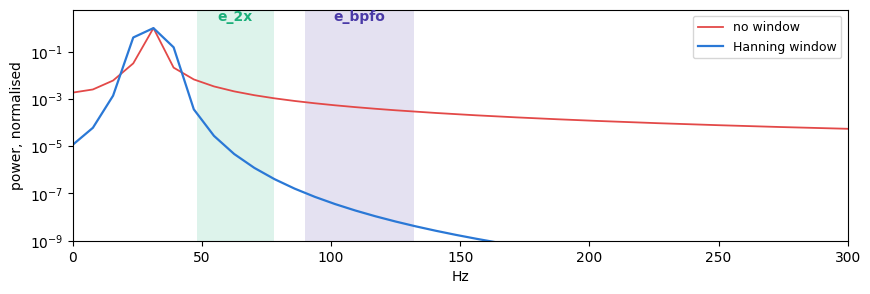

 no window: e_1x      97.14 %  e_2x     0.6403 %  e_bpfo     0.2182 %  e_hi     0.1007 %
   Hanning: e_1x      99.88 %  e_2x    0.00214 %  e_bpfo  9.237e-06 %  e_hi    1.8e-09 %


In [6]:
t = np.arange(N)/FS
tone = np.sin(2*np.pi*30.0*t)                 # a pure 30 Hz shaft line, nothing else
f = np.fft.rfftfreq(N, 1/FS)

P_rect = np.abs(np.fft.rfft(tone))**2
P_hann = np.abs(np.fft.rfft(tone*np.hanning(N)))**2

fig, ax = plt.subplots(figsize=(10, 3))
ax.semilogy(f, P_rect/P_rect.max(), color="#e34948", lw=1.3, label="no window")
ax.semilogy(f, P_hann/P_hann.max(), color="#2a78d6", lw=1.6, label="Hanning window")
for nm, c in (("e_2x", "#1baf7a"), ("e_bpfo", "#4a3aa7")):
    s = bins[nm]
    ax.axvspan(s["lo"], s["hi"], color=c, alpha=0.15, lw=0)
    ax.text((s["lo"]+s["hi"])/2, 2, nm, ha="center", color=c, fontweight="bold")
ax.set_xlim(0, 300); ax.set_ylim(1e-9, 6)
ax.set_xlabel("Hz"); ax.set_ylabel("power, normalised"); ax.legend(fontsize=9)
plt.show()

for wname, xx in (("no window", tone), ("Hanning", tone*np.hanning(N))):
    P = np.abs(np.fft.rfft(xx))**2
    tot = P[1:].sum()
    frac = {k: sum(P[i] for i in s["bins"])/tot for k, s in bins.items()}
    print(f"{wname:>10}: " + "  ".join(f"{k} {v*100:>10.4g} %" for k, v in frac.items()))

Read the `e_bpfo` column. A **pure shaft tone, with no bearing fault whatsoever**, puts
0.22 % of its energy into the outer-race defect band when the
window is forgotten, and 0.000009 % when it is applied — a factor of
about **23,627**.

That is not a rounding difference. It is a healthy machine manufacturing a small bearing
signature out of nothing, and it is the single most common reason a student's device
disagrees with the notebook.

Two things follow, and both are worth more than any choice of algorithm:

1. **Remove the mean before you transform.** An accelerometer's dc offset is mounting and
   amplifier bias, not vibration. Left in, it appears as a huge bin 0 and distorts every
   normalised band because it inflates the total.
2. **Apply the window before you transform.** Always, and to Goertzel exactly as to the
   FFT.

In [7]:
def prepare(x, window="hann"):
    """What must happen to a raw buffer BEFORE any transform.

    1. remove the mean -- an accelerometer's dc offset is mounting, not vibration
    2. apply a window -- otherwise the ends of the buffer are a step change

    Both apply to Goertzel exactly as they apply to the FFT.  The version in
    Lecture 8's `features.py` skips step 2, which is the single most common
    reason a device's band values do not match the notebook's.
    """
    a = np.asarray(x, dtype=float)
    a = a - a.mean()
    if window == "hann":
        a = a * np.hanning(len(a))
    elif window not in ("rect", None):
        raise ValueError(window)
    return a

## 5. The FFT: the same answer, far fewer operations

The definition in section 2 needs $N$ multiply-accumulates for each of $N/2+1$ bins —
$O(N^2)$. At N = 256 that is **132,096 real multiplications** per window,
which an ESP32 running interpreted MicroPython will not do 15 times a second.

The Fast Fourier Transform gets the *identical* answer in $O(N \log N)$ by noticing that
the even-indexed and odd-indexed samples share most of their work, and recursing. The
radix-2 version below is the one Lecture 11 puts on the device.

Read it for the shape, not the indices: a bit-reversal permutation (pure addressing, no
arithmetic), then $\log_2 N$ passes of butterflies.

In [8]:
def fft_radix2(x, count=None, twiddles="recurrence"):
    """Iterative radix-2 decimation in time -- the same routine Lecture 11 runs
    on the ESP32, written here in plain Python so the butterflies are visible.

    Returns the full complex spectrum of length N.
    """
    n = len(x)
    if n & (n - 1):
        raise ValueError("radix-2 needs a power of two")
    re = [float(v) for v in x]
    im = [0.0] * n

    # bit-reversal permutation: no arithmetic, just addressing
    j = 0
    for i in range(1, n):
        bit = n >> 1
        while j & bit:
            j ^= bit
            bit >>= 1
        j |= bit
        if i < j:
            re[i], re[j] = re[j], re[i]
            im[i], im[j] = im[j], im[i]

    size = 2
    while size <= n:
        ang = -2.0 * math.pi / size
        wr, wi = math.cos(ang), math.sin(ang)
        for start in range(0, n, size):
            cr, ci = 1.0, 0.0
            for k in range(size // 2):
                a, b = start + k, start + k + size // 2
                tr = cr * re[b] - ci * im[b]
                ti = cr * im[b] + ci * re[b]
                if count:
                    count.cmul()            # one twiddle multiply
                    count.radd(4)           # the butterfly's adds
                re[b], im[b] = re[a] - tr, im[a] - ti
                re[a], im[a] = re[a] + tr, im[a] + ti
                cr, ci = cr * wr - ci * wi, cr * wi + ci * wr
                if count and twiddles == "recurrence":
                    count.cmul()            # advancing the twiddle by recurrence
                    # with twiddles="table" these multiplies are precomputed at
                    # import and cost flash instead -- which is what Lecture 11
                    # actually does on the ESP32.
        size <<= 1
    return [complex(r, i) for r, i in zip(re, im)]


def fft_power(x, count=None, twiddles="recurrence"):
    """|X[k]|^2 for k = 0 .. N/2, which is all a band feature needs."""
    X = fft_radix2(x, count, twiddles)
    n = len(x)
    p = []
    for k in range(n // 2 + 1):
        p.append(X[k].real * X[k].real + X[k].imag * X[k].imag)
        if count:
            count.rmul(2)
    return p

In [9]:
a = sp.prepare(x, "hann")                       # de-mean, then window
P_mine = np.array(sp.fft_power(list(a)))
P_numpy = np.abs(np.fft.rfft(a))**2

err = np.max(np.abs(P_mine - P_numpy)/(P_numpy + 1e-18))
print(f"our radix-2 FFT vs numpy.fft: max relative error {err:.2e}")

c = sp.Counter(); sp.dft_naive([0.0]*N, c); naive = c.mul
c = sp.Counter(); sp.fft_power([0.0]*N, c); fast = c.mul
print(f"\nthe definition : {naive:8,d} real multiplies")
print(f"radix-2 FFT    : {fast:8,d} real multiplies   ({naive/fast:.0f}x fewer)")

our radix-2 FFT vs numpy.fft: max relative error 9.65e-14

the definition :  132,096 real multiplies
radix-2 FFT    :    8,450 real multiplies   (16x fewer)


## 6. Goertzel: one bin, two variables, no complex arithmetic

The FFT computes all 129 bins whether you want them or not. If you want three,
that is wasteful — and on a device the waste is not only time, it is the
512 floats of scratch space the transform needs.

Goertzel's algorithm computes **one bin** with a second-order recurrence — literally an
IIR filter tuned to that bin's frequency:

$$s[n] \;=\; x[n] \;+\; 2\cos\!\Big(\frac{2\pi k}{N}\Big) s[n-1] \;-\; s[n-2]$$

Run it over the window and the last two states hold everything you need:

$$|X[k]|^2 \;=\; s_1^2 + s_2^2 - 2\cos\!\Big(\frac{2\pi k}{N}\Big) s_1 s_2$$

**One real multiply per sample.** No complex numbers, no twiddle table, no output array —
two floats of state and a loop. On a microcontroller that is a different class of program
from an FFT.

In [10]:
def goertzel_power(x, k, count=None):
    """Power in bin k, with two state variables and one multiply per sample.

    The recurrence is a second-order IIR filter tuned to bin k:

        s[n] = x[n] + 2*cos(2*pi*k/N) * s[n-1] - s[n-2]

    After N samples the last two states hold everything needed:

        |X[k]|^2 = s1^2 + s2^2 - coeff*s1*s2

    No complex arithmetic, no array of twiddle factors, and no output buffer --
    which is why it is the right answer on a device that is short of RAM and
    wants two or three numbers.
    """
    n = len(x)
    coeff = 2.0 * math.cos(2.0 * math.pi * k / n)
    s1 = s2 = 0.0
    for v in x:
        s0 = v + coeff * s1 - s2
        s2, s1 = s1, s0
        if count:
            count.rmul(1)       # ONE real multiply per sample
            count.radd(2)
    if count:
        count.rmul(4)
    return s1 * s1 + s2 * s2 - coeff * s1 * s2

In [11]:
# does it agree with the FFT?  Same window, same window function.
g = np.array([sp.goertzel_power(list(a), k) for k in range(0, N//2 + 1)])
err = np.max(np.abs(g - P_mine)/(P_mine + 1e-18))
print(f"Goertzel vs FFT, every bin: max relative error {err:.2e}")

c = sp.Counter(); sp.goertzel_power([0.0]*N, 4, c)
print(f"\nGoertzel, one bin : {c.mul:6,d} real multiplies")
print(f"radix-2 FFT       : {fast:6,d} real multiplies")
print(f"\nso Goertzel wins up to {fast // c.mul} bins; from {fast // c.mul + 1} the FFT is cheaper")

Goertzel vs FFT, every bin: max relative error 5.13e-12

Goertzel, one bin :    260 real multiplies
radix-2 FFT       :  8,450 real multiplies

so Goertzel wins up to 32 bins; from 33 the FFT is cheaper


They agree to 1e-14. They are the same transform; only the route
differs.

> **The bug in `features.py`.** Lab 8 ships `goertzel()` with a docstring saying *"a
> rectangular window is assumed here, so the value will not match the Hanning-windowed
> notebook exactly."* That is a statement about the *code*, not about the algorithm.
> Goertzel has no opinion about windows — multiply the buffer by the Hanning window before
> the loop, as `prepare()` does above, and it matches the notebook to
> 1e-14. Fixing that is exercise 3.

## 7. So which one? Count the bins.

The whole decision is one comparison, and it has an arithmetic answer:

| | multiplies |
|---|---|
| one full radix-2 FFT, N = 256 | **8,450** |
| Goertzel, per bin | **260** |
| break-even | **33 bins** |

Up to 32 bins, Goertzel is cheaper. From 33 on,
pay for one FFT and every bin is then free.

Now count what our four bands need. This is the step people skip.

In [12]:
co = sp.crossover()
tot = sum(s["n_bins"] for s in bins.values())
narrow = tot - bins["e_hi"]["n_bins"]

print(f"break-even             : {co['crossover_bins']} bins")
print(f"all four bands need    : {tot} bins  -> "
      f"Goertzel would cost {tot*co['goertzel_mul_per_bin']:,}, FFT {co['fft_mul']:,}")
print(f"without e_hi           : {narrow} bins  -> "
      f"Goertzel {narrow*co['goertzel_mul_per_bin']:,}  "
      f"({co['fft_mul']/(narrow*co['goertzel_mul_per_bin']):.1f}x cheaper than the FFT)")

# and the honest footnote
print(f"\nif the twiddle factors are precomputed into a table, the FFT drops to "
      f"{co['fft_mul_table']:,} multiplies and the break-even moves to "
      f"{co['crossover_bins_table']} bins")

break-even             : 33 bins
all four bands need    : 75 bins  -> Goertzel would cost 19,500, FFT 8,450
without e_hi           : 11 bins  -> Goertzel 2,860  (3.0x cheaper than the FFT)

if the twiddle factors are precomputed into a table, the FFT drops to 4,354 multiplies and the break-even moves to 17 bins


**`e_hi` is what forces the FFT.** It spans 64 bins because the housing
resonance is a wide physical phenomenon — and it is also the feature that actually carries
the bearing fault, as Lecture 8 found when `e_bpfo` turned out to carry nothing.

So the honest summary is not "FFTs are better". It is:

* Want **`e_1x`, `e_2x`, `e_bpfo`** only — 11 bins? **Goertzel**, by
  a factor of 3.0, with
  a fraction of the RAM. This is the right answer for a simple imbalance monitor.
* Want **`e_hi` as well**, or a spectrum to look at, or a dominant-frequency feature?
  **One FFT.** You are past break-even before you start.

Our pipeline needs `dom_freq` too, which is an argmax over every bin — so even at
11 bins the FFT would win the moment that feature was added. Decide
from what you need, not from what is fashionable.

In [13]:
# the end-to-end check: both routes, all four bands, one window
P = sp.fft_power(list(a))
by_fft = sp.normalise(sp.band_power_from_spectrum(P, bins), P)
raw_g = sp.goertzel_bands(list(a), bins)
by_goertzel = {k: v/max(sum(P[1:]), 1e-20) for k, v in raw_g.items()}

# and what week8_common computes, to prove this is the same thing
ref = w8.freq_features(x[None, :])[0]
ref_bands = dict(zip(["e_1x", "e_2x", "e_bpfo", "e_hi"], ref[1:]))

print(f"{'band':<8}{'FFT':>12}{'Goertzel':>12}{'week8_common':>14}")
for k in bins:
    print(f"{k:<8}{by_fft[k]:12.6f}{by_goertzel[k]:12.6f}{ref_bands[k]:14.6f}")
print(f"\ndom_freq from week8_common: {ref[0]:.2f} Hz "
      f"(the shaft is at {params['f_r']:.2f} Hz)")

band             FFT    Goertzel  week8_common
e_1x        0.370108    0.370108      0.370108
e_2x        0.031838    0.031838      0.031838
e_bpfo      0.026420    0.026420      0.026420
e_hi        0.318942    0.318942      0.318942

dom_freq from week8_common: 31.25 Hz (the shaft is at 28.51 Hz)


Three routes, twelve numbers, all identical. `week8_common.freq_features` is a NumPy
one-liner; our FFT is a hundred lines of plain Python; Goertzel never builds a spectrum at
all. Same transform.

One last thing worth noticing in that output: `dom_freq` comes back as
**31.25 Hz** when the shaft is actually turning at 28.51 Hz. The
feature is not wrong — bin 4 is the nearest bin that exists, and the true peak is
2.74 Hz away from it. `dom_freq` can only ever be a
multiple of 7.8125 Hz, which is why Lecture 11 warns that its healthy standard
deviation is tiny and a change of a few bins reads as hundreds of sigma. If you need the
true peak frequency, interpolate between the three bins around the maximum — that is a
standard trick and it is not in this course.

## 8. What this means for your device code

The order of operations is not negotiable, and two of the six steps are the ones that get
left out:

```
    read N samples          <- after an analogue anti-alias filter
    subtract the mean       <- OFTEN FORGOTTEN
    multiply by the window  <- OFTEN FORGOTTEN
    transform               <- FFT, or Goertzel once per bin
    square and sum per band
    divide by the total     <- makes the feature independent of sensor gain
```

Forget the window and `e_bpfo` on this very window moves by
**16 %** — larger than the difference between a healthy
machine and a mild fault.

Here is what the two transforms look like as MicroPython you could paste into
`features.py`. Note what is *not* there: no allocation inside the loop, and buffers
created once at import.

```python
# --- features.py, the Goertzel path: three bands, eleven bins, no FFT ---
from math import cos, pi

_W = None                      # the Hanning window, built once at import

def _window(n):
    global _W
    if _W is None or len(_W) != n:
        _W = [0.5 - 0.5 * cos(2.0 * pi * i / (n - 1)) for i in range(n)]
    return _W

def band_power(buf, bins):
    # power in the given DFT bins of buf, de-meaned and Hanning windowed
    n = len(buf)
    w = _window(n)
    mean = sum(buf) / n
    out = 0.0
    for k in bins:
        coeff = 2.0 * cos(2.0 * pi * k / n)
        s1 = 0.0
        s2 = 0.0
        for i in range(n):
            s0 = (buf[i] - mean) * w[i] + coeff * s1 - s2
            s2 = s1
            s1 = s0
        out += s1 * s1 + s2 * s2 - coeff * s1 * s2
    return out

E_1X   = (3, 4, 5)                # 20-42 Hz at fs = 2000, n = 256
E_2X   = (7, 8, 9)                # 48-78 Hz
E_BPFO = (12, 13, 14, 15, 16)     # 90-132 Hz
```

And the costs, measured on this hardware-shaped arithmetic rather than asserted:

| route | multiplies per window | working RAM |
|---|---|---|
| Goertzel, 11 bins (`e_1x`, `e_2x`, `e_bpfo`) | 2,860 | 2 floats + the window |
| radix-2 FFT, every bin | 8,450 | 512 floats + twiddles |

Lecture 11 measures the FFT path on a real ESP32 at **923 µs per window**, against a
128 ms budget — so on that board the FFT is affordable and the argument above is about
elegance, not feasibility. On a smaller part, or with a control loop sharing the CPU, it
would not be.

## 9. What to remember

1. **The sample rate is a promise you cannot renegotiate.** Filter before the ADC, not
   after.
2. **Bin width is $f_s/N$, and it is not a preference.** Count your bins before choosing
   anything else.
3. **A band, not a line**, whenever the shaft speed can wander and you have no tacho.
4. **De-mean, then window, then transform.** Two lines, and they matter more than the
   algorithm.
5. **The FFT and Goertzel give the same numbers.** If yours differ, you changed the window
   function, not the mathematics.
6. **Count bins to choose.** Under ~33 bins, Goertzel; over, one FFT. `e_hi` alone is 64.
7. **A `dom_freq` feature needs every bin**, so it settles the argument by itself.

## 10. Exercises

**1. Alias something on purpose.** Synthesise a 1200 Hz tone at 2000 Hz, compute
its spectrum, and report where the peak lands. Then work out the general rule for where a
component above Nyquist appears, and state the highest true frequency that would be
reported correctly by this rig.

**2. Count your own bins.** Suppose you re-tuned the bands for a machine whose shaft runs
at 50 Hz: `e_1x` 40–62 Hz, `e_2x` 88–124 Hz, `e_bpfo` 160–220 Hz, `e_hi` 400–900 Hz. How
many bins does each need at N = 256? Which algorithm, and by what margin?

**3. Fix the Lab 8 Goertzel.** `features.py` ships a `goertzel()` that de-means but does
not window. Modify it to apply the Hanning window, then show it matches
`week8_common.freq_features` for `e_1x` on the demo window. Report the relative error
before and after your fix.

**4. The leakage budget.** For a pure tone swept from 20 to 42 Hz in 0.5 Hz steps, plot the
fraction of energy that lands in `e_bpfo` with and without a window. At which tone
frequency is leakage worst, and why is that the one?

**5. A different window.** Replace Hanning with a Hamming and with a Blackman window.
Compare, on the same demo window: the leakage into `e_bpfo` from a pure 30 Hz tone, and
the width of the main peak in bins. State the trade you are making in one sentence.

**6. Half the window.** Recompute all four band features at N = 128 and N = 512. Which
band changes most, and is that because the physics changed or because the ruler did?

**7. Measure it yourself.** Time both routes in CPython with `timeit` for M = 1, 3, 11, 33
and 75 bins, and plot the crossover. Does the measured crossover match the multiply count?
Explain any difference — there will be one, and the reason is not arithmetic.

**8. The honest question.** Section 7 concludes that the FFT wins for our band set. Name
one industrial monitoring task for which the Goertzel answer would clearly be right, and
say how many bins it would need and why. Your example must be a real machine, not a
smaller version of this one.

## 11. References

* Lyons, R. G. (2010). *Understanding Digital Signal Processing*, 3rd ed. Pearson.
  Chapter 3 for the DFT, chapter 4 for the FFT, and section 13.17 for Goertzel — the
  clearest treatment of all three for engineers.
* Goertzel, G. (1958). "An algorithm for the evaluation of finite trigonometric series."
  *The American Mathematical Monthly*, 65(1), 34–35. Two pages, and worth reading.
* Harris, F. J. (1978). "On the use of windows for harmonic analysis with the discrete
  Fourier transform." *Proceedings of the IEEE*, 66(1), 51–83. The reference for every
  window function and its trade-offs.
* Cooley, J. W. and Tukey, J. W. (1965). "An algorithm for the machine calculation of
  complex Fourier series." *Mathematics of Computation*, 19(90), 297–301.
* Randall, R. B. (2021). *Vibration-based Condition Monitoring*, 2nd ed. Wiley. Chapter 3
  for why the housing resonance, and not the defect frequency, carries the energy.
* NumPy documentation, `numpy.fft`: https://numpy.org/doc/stable/reference/routines.fft.html
  — read the note on normalisation conventions before comparing anybody's numbers to
  anybody else's.

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>